In [ ]:
import pandas as pd
wine =  pd.read_csv('https://bit.ly/wine_csv_data')
#print(wine.tail())
#print(wine.info())
#print(wine.describe())

data = wine[['alcohol','sugar','pH']].to_numpy()
target = wine['class'].to_numpy()

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)
#print(train_input.shape, test_input.shape)

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

print(lr.coef_, lr.intercept_)



0.7808350971714451
0.7776923076923077
[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))
total_depth =  dt.get_depth()
print("트리의 총 깊이:",dt.get_depth() )

0.996921300750433
0.8592307692307692
트리의 총 깊이: 21


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

In [ ]:
plt.figure(figsize=(10,7))
plot_tree(dt, max_depth=2, filled=True, feature_names=['alcohol','sugar','pH'])
plt.show()

In [ ]:
tree = dt.tree_

# for node in range(tree.node_count):
#     print(
#         f"Node {node}: ",
#         f"gini={tree.impurity[node]:.4f}, "
#         f"samples={tree.n_node_samples[node]}, "
#         f"value={tree.value[node][0]}" )


from sklearn.tree import _tree
for node in range(tree.node_count):
    if tree.children_left[node] == _tree.TREE_LEAF:

        print(
            f"Leaf Node {node}: "
            f"gini={tree.impurity[node]:.4f}, "
            f"samples={tree.n_node_samples[node]}, "
            f"value={tree.value[node][0]}"
        )

In [ ]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))


0.8454877814123533
0.8415384615384616


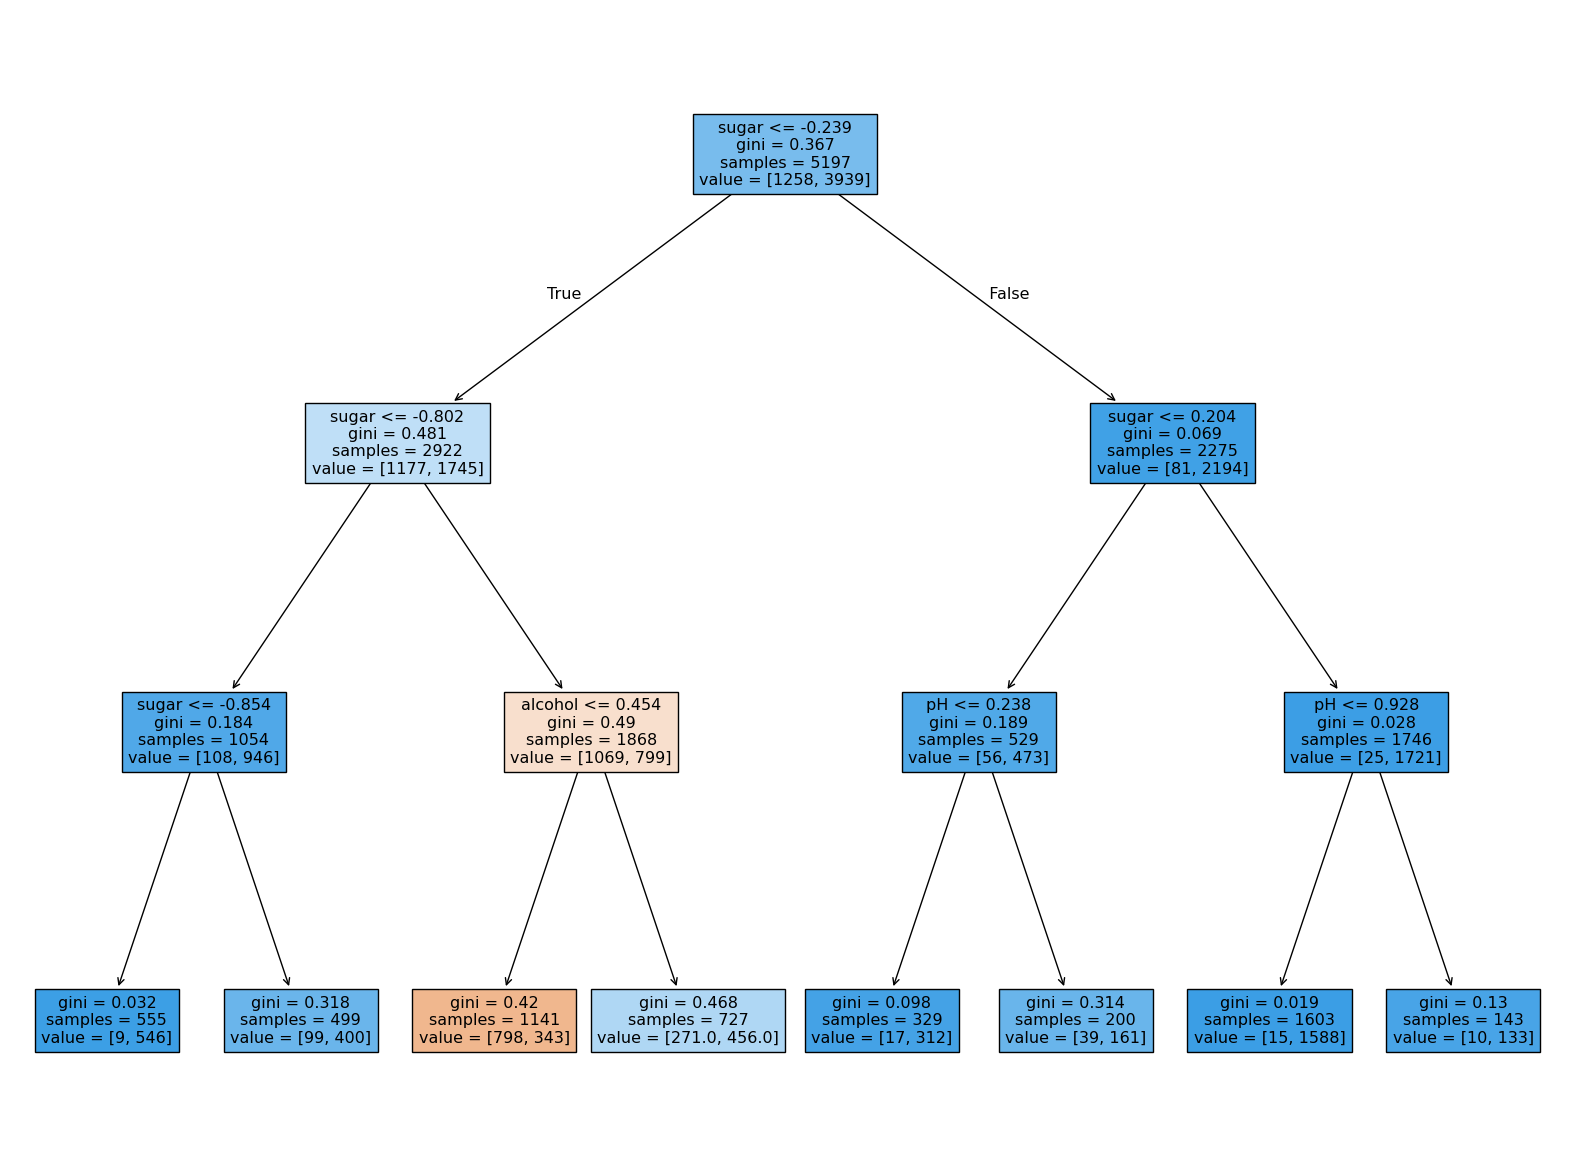

In [ ]:
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [ ]:
print(dt.feature_importances_)

[0.12345626 0.86862934 0.0079144 ]


In [ ]:
import pandas as pd
wine =  pd.read_csv('https://bit.ly/wine_csv_data')

data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

In [ ]:
# 검증세트????

sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

# (1) 검증세트는 왜 필요한가?

print(sub_input.shape, val_input.shape)

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(sub_input, sub_target)

print(dt.score(sub_input, sub_target))
print(dt.score(val_input, val_target))

# 훈련세트와 검증세트의 정확도 출력
#(4157, 3) (1040, 3)
#0.9971133028626413
#0.864423076923077

# (2) 교차검증은 무엇이고 왜 하지?
# (3) cross_validate 교차검증 함수는?
from sklearn.model_selection import cross_validate
import numpy as np

scores = cross_validate(dt, train_input, train_target, cv=5)
print(scores)
# (4) cross_validate 교차검증 함수의 결과 해석은 어떻게?
# {'fit_time': array([0.01044607, 0.00870395, 0.00942945, 0.00899911, 0.00841832]),
# 'score_time': array([0.00184202, 0.00137687, 0.00133729, 0.00135016, 0.00128388]),
# 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}

print(np.mean(scores['test_score']))
# 0.855300214703487


# (5) StratifiedKFold 함수???

from sklearn.model_selection import StratifiedKFold
####???
scores = cross_validate(dt, train_input, train_target, cv=StratifiedKFold())

print(np.mean(scores['test_score']))
# 0.855300214703487

####???
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(dt, train_input, train_target, cv=splitter)
print(np.mean(scores['test_score']))
# 0.8574181117533719


#하이퍼 파라미터 튜닝 ????
# (6) 하이터파라미터란?  VS. 모델 파라미터란?
# (7) 왜 하이퍼 파라미터 튜닝이 필요한가?
# (8) 그리드 서치가 무엇인가? GridSearchCV 역할?

from sklearn.model_selection import GridSearchCV
import numpy as np

params = {'min_impurity_decrease': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)
gs.fit(train_input, train_target)

#(9) GridSearchCV 주요 속성들?
dt = gs.best_estimator_
print("하이퍼 파라미터 튜닝 결과")
print(dt.score(train_input, train_target))

print(gs.best_params_)
print(gs.cv_results_['mean_test_score'])

best_index = np.argmax(gs.cv_results_['mean_test_score'])
print(gs.cv_results_['params'][best_index])

# (10) 하이퍼 파라미터 튜닝 결과 해석
# 0.9615162593804117
# {'min_impurity_decrease': 0.0001}
# [0.86819297 0.86453617 0.86492226 0.86780891 0.86761605]
# {'min_impurity_decrease': 0.0001}

params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
          'max_depth': range(5, 20, 1),
          'min_samples_split': range(2, 100, 10)
          }

gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)
gs.fit(train_input, train_target)
print(gs.best_params_)
print(np.max(gs.cv_results_['mean_test_score']))

# (10) 하이퍼 파라미터 튜닝 결과 해석
# {'max_depth': 14, 'min_impurity_decrease': np.float64(0.0004), 'min_samples_split': 12}
# 0.8683865773302731


# 랜덤 서치?????
#(11) 랜덤서치는 왜 하지?

from scipy.stats import uniform, randint
rgen = randint(0, 10)
rgen.rvs(10)

np.unique(rgen.rvs(1000), return_counts=True)

ugen = uniform(0, 1)
ugen.rvs(10)

params = {'min_impurity_decrease': uniform(0.0001, 0.001),
          'max_depth': randint(20, 50),
          'min_samples_split': randint(2, 25),
          'min_samples_leaf': randint(1, 25),
          }

from sklearn.model_selection import RandomizedSearchCV

gs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params,
                        n_iter=100, n_jobs=-1, random_state=42)
gs.fit(train_input, train_target)
print(gs.best_params_)
print(np.max(gs.cv_results_['mean_test_score']))

dt = gs.best_estimator_
print(dt.score(test_input, test_target))